In [112]:
from sklearn.datasets import load_iris
# import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import joblib

In [113]:
iris_data = load_iris()
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [114]:
X = iris_data.data
y = iris_data.target

In [115]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [116]:
dt = DecisionTreeClassifier(criterion='entropy',
                            splitter='best',
                            max_depth=100,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            random_state=42)
dt.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [117]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [118]:
print(f"Accuracy Score Train : {accuracy_score(y_train,y_train_pred)}")
print(f"Accuracy Score Test : {accuracy_score(y_test,y_test_pred)}")

Accuracy Score Train : 1.0
Accuracy Score Test : 0.9333333333333333


In [119]:
print(f"Test Confusion Matrix : \n{confusion_matrix(y_test,y_test_pred)}")

Test Confusion Matrix : 
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [120]:
print(f"Test Classification Report : \n{classification_report(y_test,y_test_pred)}")

Test Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [121]:
importance = dt.feature_importances_
print(f"Feature Importance For Cassification : ")
for col,val in zip(iris_data.feature_names,importance):
    print(f"{col} : {val*100:.4f}")

Feature Importance For Cassification : 
sepal length (cm) : 0.6546
sepal width (cm) : 2.5000
petal length (cm) : 66.4888
petal width (cm) : 30.3565


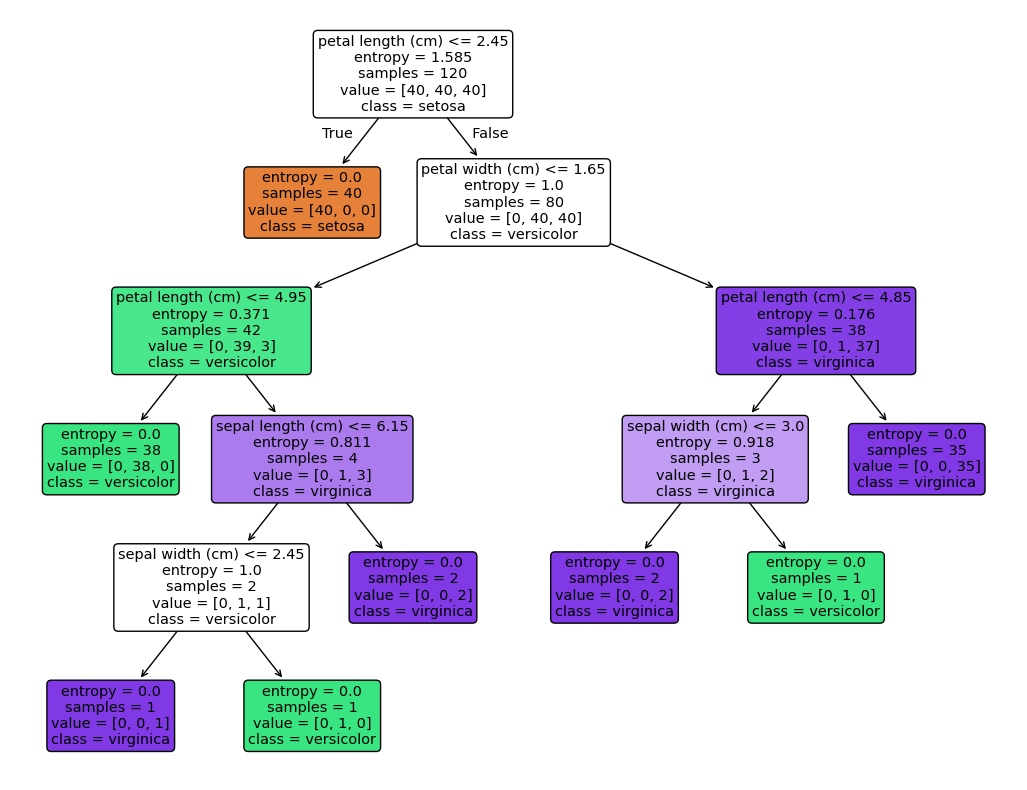

In [122]:
plt.figure(figsize=(13,10))
plot_tree(
    dt,
    feature_names=iris_data.feature_names,
    class_names=iris_data.target_names,
    filled=True,
    rounded=True    
)
plt.show()

In [123]:
joblib.dump(dt,"decision_tree_model.pkl")
print("Model Saved !")

Model Saved !


In [124]:
loaded_model = joblib.load("decision_tree_model.pkl")

In [125]:
def sample_predict(sepal_length,sepal_width,petal_length,petal_width):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = loaded_model.predict(features)
    proba = loaded_model.predict_proba(features)
    class_pred = iris_data.target_names[prediction]
    for i,j,k in zip(prediction,proba,class_pred):
        print(i,j,k)

In [ ]:
sample_predict(5.7, 3.1, 4.9, 2.0)      

2 [0. 0. 1.] virginica


## Random Forest Classification : <br>
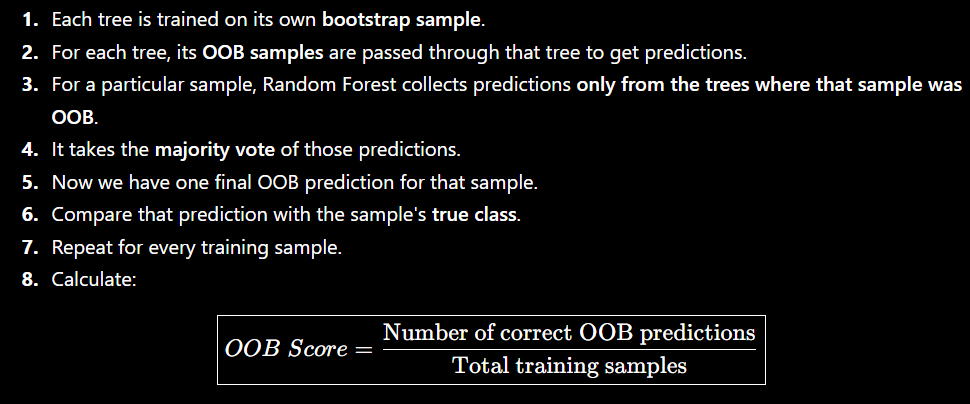

In [127]:
from sklearn.ensemble import RandomForestClassifier

In [128]:
rf = RandomForestClassifier(
    n_estimators = 100,
    criterion='gini',
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    max_features='sqrt',
    random_state=42
)

In [129]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [130]:
y_test_pred_rf= rf.predict(X_test)
print(f"Accuracy Score Test : {accuracy_score(y_test,y_test_pred_rf)}")

Accuracy Score Test : 0.9666666666666667


In [131]:
print("OOB score : ",rf.oob_score_)

OOB score :  0.9583333333333334


In [132]:
confusion_matrix(y_test,y_test_pred_rf)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

In [133]:
print(f"Test Classification Report of Random Forest : \n{classification_report(y_test,y_test_pred_rf)}")

Test Classification Report of Random Forest : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [134]:
# iris_data.target_names
importance = rf.feature_importances_
print(f"Feature Importance For Cassification : ")
for col,val in zip(iris_data.feature_names,importance):
    print(f"{col} : {val*100:.4f}")

Feature Importance For Cassification : 
sepal length (cm) : 11.5645
sepal width (cm) : 1.0754
petal length (cm) : 43.7745
petal width (cm) : 43.5857


In [135]:
joblib.dump(rf,"random_forest_model.pkl")
print("Model Saved !")

Model Saved !


In [136]:
loaded_model_rf = joblib.load("random_forest_model.pkl")
def sample_predict_rf(sepal_length,sepal_width,petal_length,petal_width):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = loaded_model_rf.predict(features)
    proba = loaded_model_rf.predict_proba(features)
    class_pred = iris_data.target_names[prediction]
    for i,j,k in zip(prediction,proba,class_pred):
        print(i,j,k)

In [137]:
sample_predict_rf(5.7, 3.1, 4.9, 2.0)

2 [0.         0.16465361 0.83534639] virginica
